# 02.6 -- The separator: does a trained net's curvature survive when the surface is right?

`02.6-FINDINGS.md` Section 4 found the halted phase's ranking axis was a composite of three
separable properties -- did the architecture learn the right surface, are that trained net's
second derivatives trustworthy, is pullback the right approximator -- and never separated the
middle one from the first. This notebook holds the surface fixed by construction: a net is fit
to the Swiss roll's own ANALYTIC parameterization, so the surface it is asked to represent is
correct in advance rather than learned, and the only remaining variable is whether a net's
second derivatives survive being differentiated. Section 8.3 names this experiment.

**This is D-14: non-blocking.** Its result is recorded here and gates nothing -- the
persistent-homology ranking this phase runs proceeds regardless of what this notebook finds.

**D-15's two branches, written down before any number below is shown:**

- **Separator FAILS** -- the PH ranking still continues and is reported, but the phase records
  explicitly that no curvature claim attaches to any substrate, and `02.5-10` inherits "Arm B
  through a trained decoder is not viable" and must redesign stage 2 around it.
- **Separator PASSES** -- nets can carry usable second derivatives when the surface is right,
  which means the halted phase's low scores were about architectures failing to learn the
  sheet, not about net derivatives in general.

Nothing here is pre-registered, cached, or gated. It fits in about two minutes.


## Section 1. Setup

In [1]:
import sys
import time
from pathlib import Path

# import pu_manifold exactly as the other notebooks do -- relative, never from src/effdim/
NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.datasets import make_swiss_roll

from pu_manifold import analytic_param, cae, chart_curvature, curvature_probe
from pu_manifold import decoder_curvature as dc

NOTEBOOK_START = time.monotonic()

SEED = 20260807          # this phase's own FIXTURE_SEED -- comparable to the diagnostics runners
N_POINTS = 3000
LATENT_DIM = 2            # the roll's true intrinsic dimension
HIDDEN_BIG = (256, 256, 256)   # generously sized, deliberately NOT budget-matched (D-12)
CFG = dict(
    seed=SEED, lr=1e-3, weight_decay=1e-4, batch=256, max_epochs=200,
    early_stop_patience=20, early_stop_min_delta=1e-4,
)
VIEW = dict(elev=12, azim=-78)  # looks along the roll's extrusion axis, so the spiral shows

print(f"torch {torch.__version__}  numpy {np.__version__}")
print(f"analytic_param module: {analytic_param.__file__}")


torch 2.13.0+cpu  numpy 2.5.1
analytic_param module: /home/akagi/Documents/Projects/EffDim/notebooks/pu_manifold/analytic_param.py


## Section 2. The roll and its exact intrinsic coordinates

3,000 noiseless points, centred and divided by one global standard deviation -- a single
scalar, so the shape is preserved. The colour is the roll's own spiral parameter `t`: colour
bands staying in order in every plot below means the surface stayed in order.

`analytic_param`'s exact arc-length / intrinsic-plane / ambient helpers are checked here
against the cloud actually generated in this notebook -- not merely against the module's own
test fixture -- before anything downstream is built on them.


X (3000, 3)
exact ambient reconstruction vs the generated cloud: max abs deviation = 0.000e+00


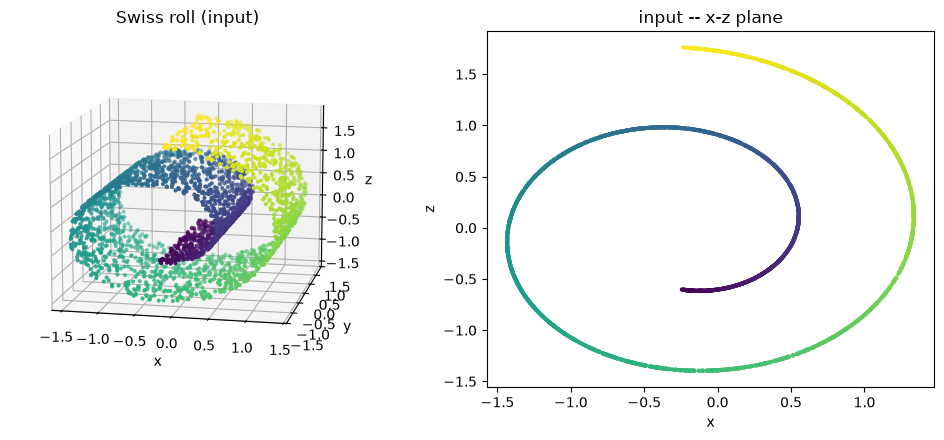

In [2]:
X_raw, t = make_swiss_roll(n_samples=N_POINTS, noise=0.0, random_state=SEED)
center = X_raw.mean(axis=0)
global_std = float(X_raw.std())
X = (X_raw - center) / global_std
y_raw = X_raw[:, 1]
y_scaled = X[:, 1]

z_intrinsic = analytic_param.swiss_roll_intrinsic_plane(t, y_scaled, global_std)
ambient_exact = analytic_param.swiss_roll_exact_ambient(t, y_raw, center, global_std)
max_dev = float(np.max(np.abs(ambient_exact - X)))
print(f"X {X.shape}")
print(f"exact ambient reconstruction vs the generated cloud: max abs deviation = {max_dev:.3e}")

fig = plt.figure(figsize=(10, 4.5))
ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=t, cmap="viridis", s=4)
ax.view_init(**VIEW)
ax.set_title("Swiss roll (input)")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")

ax2 = fig.add_subplot(1, 2, 2)
ax2.scatter(X[:, 0], X[:, 2], c=t, cmap="viridis", s=4)
ax2.set_title("input -- x-z plane")
ax2.set_xlabel("x"); ax2.set_ylabel("z")
plt.tight_layout()
plt.show()


## Section 3. The exactness floor

The Swiss roll's own closed-form decoder (`analytic_param.AnalyticSwissRollDecoder`), pushed
through the SAME `decoder_curvature.plain_decoder_curvature` unchanged, at the closed form's
own spiral-parameter coordinates. This is D-13's exactness floor: PASS below is defined as
measured degradation FROM this number, never from an abstract threshold.


In [3]:
floor_model = analytic_param.AnalyticSwissRollDecoder(center=center, global_std=global_std)
z_floor = torch.tensor(np.stack([t, y_scaled], axis=1), dtype=torch.float64)
floor_out = dc.plain_decoder_curvature(floor_model, z_floor)
H_true_all = dc.swiss_roll_analytic_H_vector(t, global_std)

floor_report = chart_curvature.curvature_fidelity_report(floor_out["H_vec"], H_true_all)
floor_rho = curvature_probe.spearman_gate_statistic(
    floor_out["H_norm"].detach().cpu().numpy(), np.linalg.norm(H_true_all, axis=-1)
)

print(f"activation (floor)       : {floor_out['activation']}")
print(f"median cosine similarity : {floor_report['median_cosine_similarity']:.9f}")
print(f"median magnitude ratio   : {floor_report['median_magnitude_ratio']:.9f}")
print(f"magnitude ratio CV       : {floor_report['magnitude_ratio_cv']:.9f}")
print(f"calibration slope        : {floor_report['calibration_slope']:.9f}")
print(f"Spearman rho             : {floor_rho:.9f}")


activation (floor)       : no-activation-modules
median cosine similarity : 1.000000000
median magnitude ratio   : 1.000000000
magnitude ratio CV       : 0.000000000
calibration slope        : 1.000000000
Spearman rho             : 1.000000000


## Section 4. The best-case net

`analytic_param.AnalyticParamDecoder(hidden=HIDDEN_BIG)` -- D-12's generously sized,
deliberately NOT budget-matched net -- fit by regression from the exact intrinsic coordinates
to the ambient cloud, on an 80/20 split, using `cae.train_mlp_decoder` UNCHANGED (no training
loop is written in this notebook or in `analytic_param.py`).


epochs_run    = 132
wallclock_s   = 7.4
early_stopped = True
held-out mean relative error = 0.0146 (1.5%)


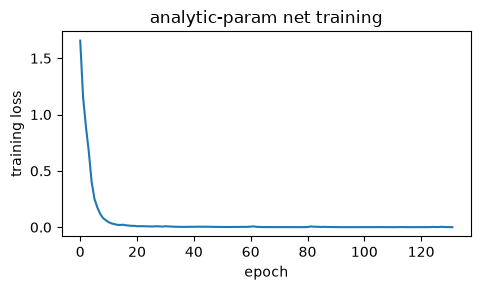

In [4]:
rng = np.random.default_rng(SEED)
perm = rng.permutation(N_POINTS)
n_train = int(0.8 * N_POINTS)
train_idx, holdout_idx = perm[:n_train], perm[n_train:]

z_all_t = torch.tensor(z_intrinsic, dtype=torch.float32)
x_all_t = torch.tensor(X, dtype=torch.float32)
z_train, x_train = z_all_t[train_idx], x_all_t[train_idx]
z_holdout, x_holdout = z_all_t[holdout_idx], x_all_t[holdout_idx]

torch.manual_seed(SEED)
net = analytic_param.AnalyticParamDecoder(hidden=HIDDEN_BIG, activation="silu")
fit = cae.train_mlp_decoder(net, z_train, x_train, CFG)
net.eval()

print(f"epochs_run    = {fit['epochs_run']}")
print(f"wallclock_s   = {fit['wallclock_s']:.1f}")
print(f"early_stopped = {fit['early_stopped']}")

with torch.no_grad():
    y_holdout = net.decode(z_holdout)
rel_err = float(
    (torch.linalg.vector_norm(x_holdout - y_holdout, dim=-1)
     / torch.linalg.vector_norm(x_holdout, dim=-1)).mean()
)
print(f"held-out mean relative error = {rel_err:.4f} ({100 * rel_err:.1f}%)")

main_history = [h for h in fit["history"] if h["stage"] == "main"]
plt.figure(figsize=(5, 3))
plt.plot([h["epoch"] for h in main_history], [h["total"] for h in main_history])
plt.xlabel("epoch"); plt.ylabel("training loss"); plt.title("analytic-param net training")
plt.tight_layout()
plt.show()


## Section 5. The reconstruction, side by side

The net's output at every fixture intrinsic coordinate, beside the input -- both a 3-D scatter
(the default view that hides the spiral) and an x-z scatter (the plane that shows it
unambiguously), coloured by `t`.


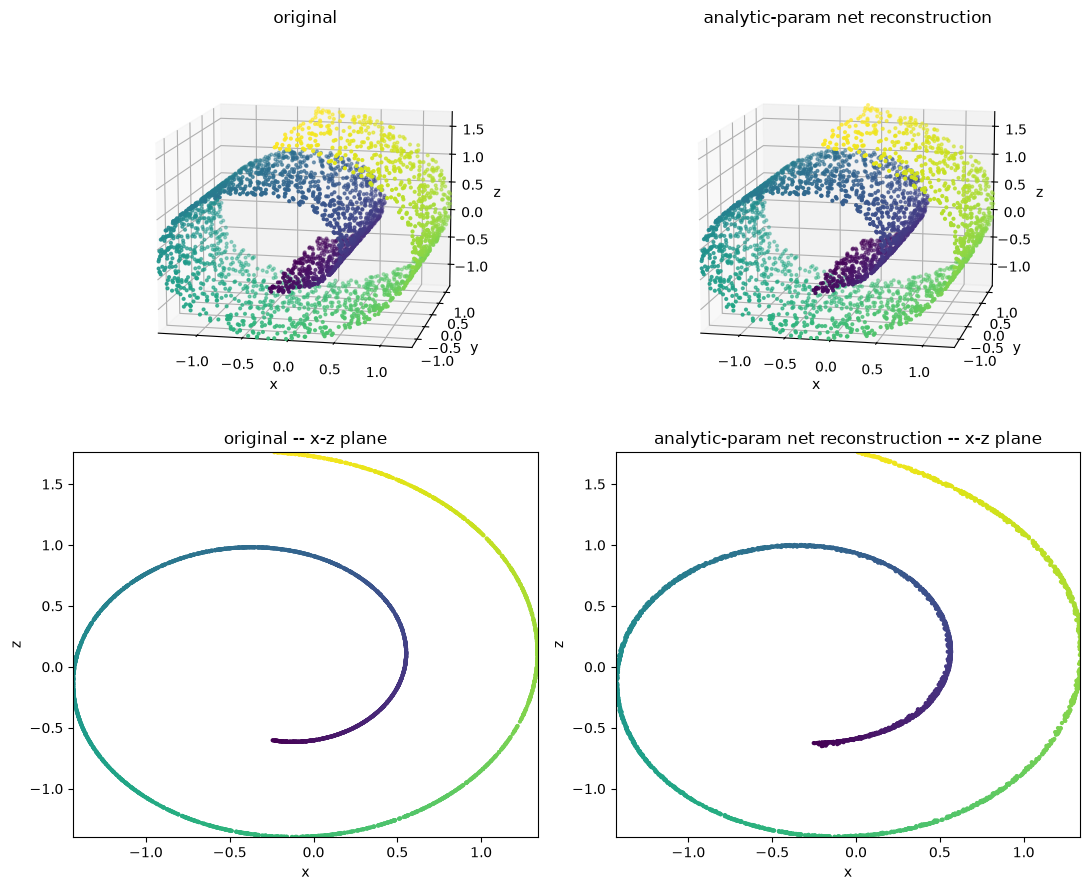

In [5]:
with torch.no_grad():
    y_all = net.decode(z_all_t).numpy()

fig = plt.figure(figsize=(11, 9))
for i, (data, title) in enumerate(
    [(X, "original"), (y_all, "analytic-param net reconstruction")]
):
    ax = fig.add_subplot(2, 2, i + 1, projection="3d")
    ax.scatter(data[:, 0], data[:, 1], data[:, 2], c=t, cmap="viridis", s=4)
    ax.view_init(**VIEW)
    ax.set_title(title)
    ax.set_xlim(X[:, 0].min(), X[:, 0].max())
    ax.set_ylim(X[:, 1].min(), X[:, 1].max())
    ax.set_zlim(X[:, 2].min(), X[:, 2].max())
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")

    ax2 = fig.add_subplot(2, 2, i + 3)
    ax2.scatter(data[:, 0], data[:, 2], c=t, cmap="viridis", s=4)
    ax2.set_title(f"{title} -- x-z plane")
    ax2.set_xlim(X[:, 0].min(), X[:, 0].max())
    ax2.set_ylim(X[:, 2].min(), X[:, 2].max())
    ax2.set_xlabel("x"); ax2.set_ylabel("z")
plt.tight_layout()
plt.show()


## Section 6. Curvature through the trained net -- the degradation

The question D-13 asks: what does replacing the analytic map with a net cost, relative to
Section 3's floor? Measured at the fixture's own points AND on a dense held-out grid (T1,
ratified in `02.6-SCREENING-RULE-02.md`), uniform in the spiral parameter `t` -- arc length is
strictly monotone in `t`, so a grid dense in one is dense in the other and no arc-length
inversion is needed. Alongside both: the CLAUDE.md-mandated matched `cae.PlainAutoEncoder`
baseline, same width, depth, protocol and 2-D bottleneck, through the identical tracer. Every
number below is reported separately -- never combined into a score.


In [6]:
net = net.double()

z_fixture64 = torch.tensor(z_intrinsic, dtype=torch.float64)
net_fixture_out = dc.plain_decoder_curvature(net, z_fixture64)
net_fixture_report = chart_curvature.curvature_fidelity_report(net_fixture_out["H_vec"], H_true_all)
net_fixture_rho = curvature_probe.spearman_gate_statistic(
    net_fixture_out["H_norm"].detach().cpu().numpy(), np.linalg.norm(H_true_all, axis=-1)
)

# dense held-out grid, uniform in the spiral parameter t (D-15, T1)
grid_rng = np.random.default_rng(SEED + 1)
t_grid = grid_rng.uniform(t.min(), t.max(), size=1000)
y_raw_grid = grid_rng.uniform(y_raw.min(), y_raw.max(), size=1000)
y_scaled_grid = (y_raw_grid - center[1]) / global_std
z_grid = analytic_param.swiss_roll_intrinsic_plane(t_grid, y_scaled_grid, global_std)
z_grid64 = torch.tensor(z_grid, dtype=torch.float64)
H_true_grid = dc.swiss_roll_analytic_H_vector(t_grid, global_std)

net_grid_out = dc.plain_decoder_curvature(net, z_grid64)
net_grid_report = chart_curvature.curvature_fidelity_report(net_grid_out["H_vec"], H_true_grid)
net_grid_rho = curvature_probe.spearman_gate_statistic(
    net_grid_out["H_norm"].detach().cpu().numpy(), np.linalg.norm(H_true_grid, axis=-1)
)

# the CLAUDE.md-mandated matched baseline: same width, depth, protocol, 2-D bottleneck
torch.manual_seed(SEED)
baseline = cae.PlainAutoEncoder(3, LATENT_DIM, hidden=HIDDEN_BIG, activation="silu")
baseline_fit = cae.train_plain_ae(baseline, x_train, CFG)
baseline.eval()
baseline = baseline.double()

X_all64 = torch.tensor(X, dtype=torch.float64)
with torch.no_grad():
    z_baseline_all = baseline.encode(X_all64)
baseline_out = dc.plain_decoder_curvature(baseline, z_baseline_all)
baseline_report = chart_curvature.curvature_fidelity_report(baseline_out["H_vec"], H_true_all)
baseline_rho = curvature_probe.spearman_gate_statistic(
    baseline_out["H_norm"].detach().cpu().numpy(), np.linalg.norm(H_true_all, axis=-1)
)
print(f"matched plain AE epochs_run = {baseline_fit['epochs_run']}, "
      f"wallclock_s = {baseline_fit['wallclock_s']:.1f}")

rows = [
    ("analytic floor", floor_report, floor_rho),
    ("analytic-param net (fixture points)", net_fixture_report, net_fixture_rho),
    ("analytic-param net (held-out grid)", net_grid_report, net_grid_rho),
    ("matched plain AE", baseline_report, baseline_rho),
]

header = (
    f"{'row':38s} {'med.cosine':>11s} {'med.ratio':>10s} {'ratio CV':>10s} "
    f"{'cal.slope':>10s} {'Spearman':>10s}"
)
print()
print(header)
print("-" * len(header))
for name, rep, rho in rows:
    print(
        f"{name:38s} {rep['median_cosine_similarity']:11.6f} "
        f"{rep['median_magnitude_ratio']:10.6f} {rep['magnitude_ratio_cv']:10.6f} "
        f"{rep['calibration_slope']:10.6f} {rho:10.6f}"
    )


matched plain AE epochs_run = 188, wallclock_s = 19.3

row                                     med.cosine  med.ratio   ratio CV  cal.slope   Spearman
----------------------------------------------------------------------------------------------
analytic floor                            1.000000   1.000000   0.000000   1.000000   1.000000
analytic-param net (fixture points)       0.999870   1.009557   0.175600   0.659172   0.839304
analytic-param net (held-out grid)        0.999871   1.010278   0.166397   0.686983   0.855063
matched plain AE                          0.996673   1.091413   7.874163   4.969612   0.280720


## Section 7. Read-out

In [7]:
AGREEMENT_TOL = 0.05

check_a = abs(floor_report["median_cosine_similarity"] - 1.0) < 1e-6
check_b = (
    net_fixture_report["median_cosine_similarity"]
    > baseline_report["median_cosine_similarity"]
)
grid_fixture_gap = abs(
    net_fixture_report["median_cosine_similarity"]
    - net_grid_report["median_cosine_similarity"]
)
check_c = grid_fixture_gap < AGREEMENT_TOL
check_d = rel_err < 0.10

print(
    f"(a) closed-form decoder reproduces the analytic answer   : {check_a}   "
    f"(floor median cosine = {floor_report['median_cosine_similarity']:.9f})"
)
print(
    f"(b) analytic-param net beats matched plain AE (fixture)  : {check_b}   "
    f"(net={net_fixture_report['median_cosine_similarity']:.6f} vs "
    f"plain AE={baseline_report['median_cosine_similarity']:.6f})"
)
print(
    f"(c) fixture-point and held-out-grid rows agree (< {AGREEMENT_TOL})     : {check_c}   "
    f"(gap = {grid_fixture_gap:.6f})"
)
print(
    f"(d) roll reconstructed, held-out relative error < 10%    : {check_d}   "
    f"({100 * rel_err:.1f}%)"
)
print()

all_checks_ok = check_a and check_b and check_c and check_d
if all_checks_ok:
    conclusion = (
        "the analytic-param net carries usable second derivatives through the same "
        "unchanged tracer that is exact on the closed-form floor -- this selects D-15's "
        "second branch: the halted phase's low scores were about architectures failing to "
        "learn the sheet, not about net derivatives in general."
    )
else:
    conclusion = (
        "the analytic-param net's curvature degrades past what these four checks accept, "
        "even though its own surface is correct by construction -- this selects D-15's "
        "first branch: no curvature claim attaches to any substrate in this phase, and "
        "02.5-10 inherits 'Arm B through a trained decoder is not viable' and must "
        "redesign stage 2 around it."
    )
print("Read-out:", conclusion)

total_wallclock_s = time.monotonic() - NOTEBOOK_START
print()
print(f"total notebook wall-clock: {total_wallclock_s:.1f}s")


(a) closed-form decoder reproduces the analytic answer   : True   (floor median cosine = 1.000000000)
(b) analytic-param net beats matched plain AE (fixture)  : True   (net=0.999870 vs plain AE=0.996673)
(c) fixture-point and held-out-grid rows agree (< 0.05)     : True   (gap = 0.000000)
(d) roll reconstructed, held-out relative error < 10%    : True   (1.5%)

Read-out: the analytic-param net carries usable second derivatives through the same unchanged tracer that is exact on the closed-form floor -- this selects D-15's second branch: the halted phase's low scores were about architectures failing to learn the sheet, not about net derivatives in general.

total notebook wall-clock: 34.3s
